In [1]:
import math as m
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib import colormaps

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

from scipy.stats import linregress
from scipy.optimize import curve_fit


import statistics as st




import functools as ft

In [2]:
path_name = '../data/radiocarbon.csv'
quan = pd.read_csv(path_name, comment='#')

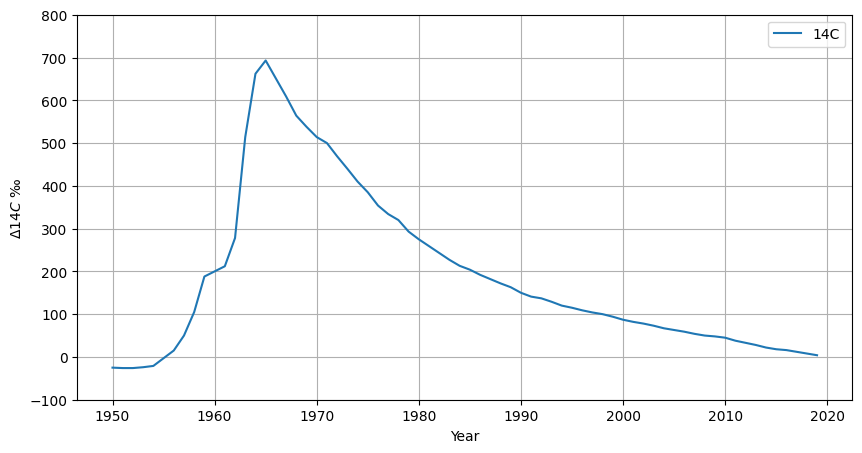

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

plt.plot(quan["year"], quan["dc14"], label="14C")
plt.xlabel("Year")
plt.ylabel("$\\Delta 14C $ \u2030 ")
plt.ylim(-100,800)
plt.grid(True)
plt.legend()
plt.savefig("../img/bombcurve.pdf")
plt.show()




In [4]:
path_name = '../data/co2_mm_mlo.csv'
mauna = pd.read_csv(path_name, comment='#')
co2 = pd.DataFrame(mauna.groupby("year")["average"].mean())

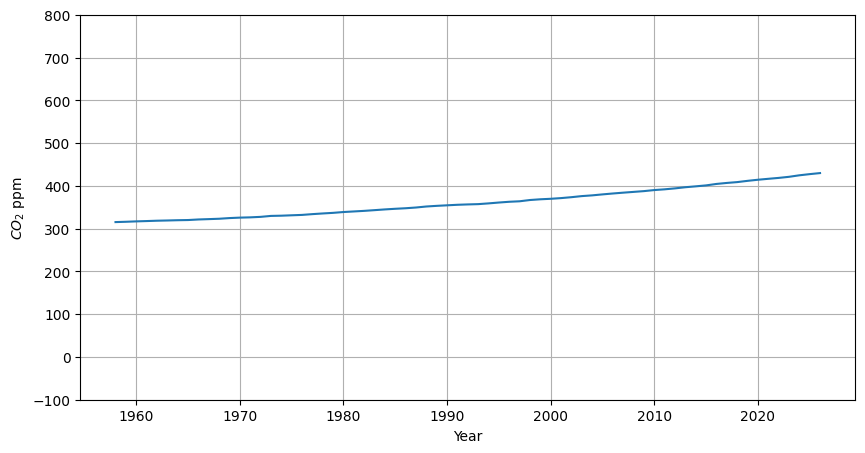

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

plt.plot(co2["average"])
plt.xlabel("Year")
plt.ylabel("$CO_{2}$ ppm")
plt.ylim(-100,800)
plt.grid(True)
plt.savefig("../img/co2.pdf")
plt.show()


In [6]:
bomb = co2.loc[(co2.index <= 2019) & (co2.index >= 1959)].rename(columns={"average" : "ppm"})
bomb["gtc"] = bomb["ppm"] * 2.13
bomb["dc14"] = (quan.loc[(quan["year"] >= 1959) & (quan["year"] <= 2019)]["dc14"].array / 1000) + 1
bomb["dc"] = bomb["ppm"] / 310  # 1955 had a concentration of 310 ppm
bomb["rdc"] = (bomb["ppm"] * bomb["dc14"] ) / 310
bomb.info()

<class 'pandas.DataFrame'>
Index: 61 entries, 1959 to 2019
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ppm     61 non-null     float64
 1   gtc     61 non-null     float64
 2   dc14    61 non-null     float64
 3   dc      61 non-null     float64
 4   rdc     61 non-null     float64
dtypes: float64(5)
memory usage: 2.9 KB


In [7]:
bomb

,ppm,gtc,dc14,dc,rdc
year,,,,,
1959,315.981667,673.040950,1.188,1.019296,1.210923
1960,316.908333,675.014750,1.200,1.022285,1.226742
1961,317.643333,676.580300,1.212,1.024656,1.241883
1962,318.453333,678.305600,1.278,1.027269,1.312850
1963,318.992500,679.454025,1.514,1.029008,1.557918
...,...,...,...,...,...
2015,401.012500,854.156625,1.018,1.293589,1.316873
2016,404.412500,861.398625,1.016,1.304556,1.325429
2017,406.758333,866.395250,1.012,1.312124,1.327869


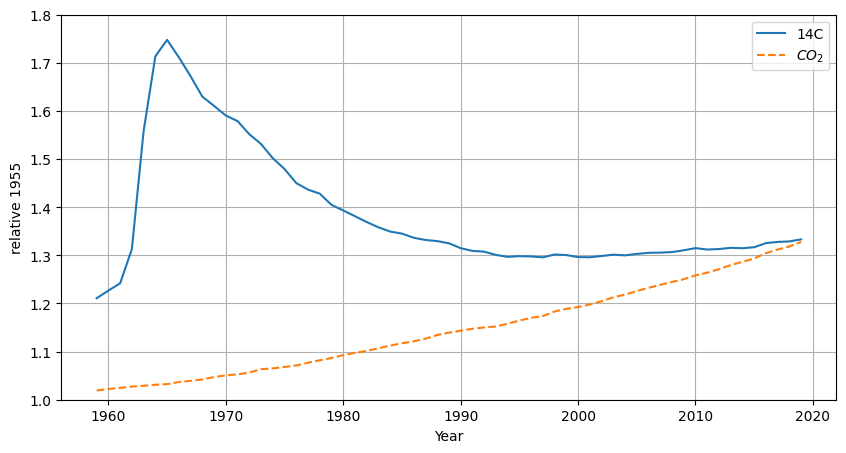

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

plt.plot(bomb.index, bomb["rdc"], label="14C")
plt.plot(bomb.index, bomb["dc"], linestyle='dashed', label="$CO_2$")
plt.xlabel("Year")
plt.ylabel("relative 1955")
plt.ylim(1,1.8)
plt.grid(True)
plt.legend()
plt.savefig("../bomb/img/relative55.pdf")
plt.show()

A = 0.7408
k = 0.0587  (tau = 17.0 years)
B = 1.0079
C = 0.005506


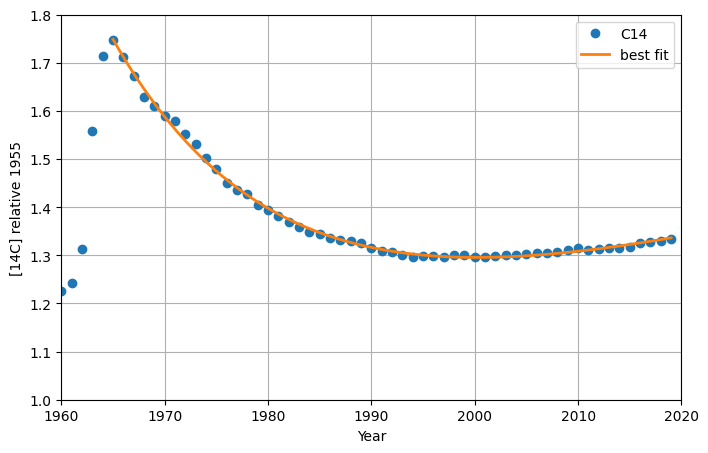

In [9]:
# Select decline period
fit = bomb.loc[1965:].copy()

x = fit.index.values
y = fit["rdc"].values

t0 = 1965

def model(x, A, k, B, C):
    return A * np.exp(-k * (x - t0)) + B + C * (x - t0)

# Initial guesses
p0 = [0.7, 0.05, 1.0, 0.0]

pars, cov = curve_fit(model, x, y, p0=p0)

A, k, B, C = pars

print(f"A = {A:.4f}")
print(f"k = {k:.4f}  (tau = {1/k:.1f} years)")
print(f"B = {B:.4f}")
print(f"C = {C:.6f}")

# Plot
xx = np.linspace(1965, 2019, 300)

plt.figure(figsize=(8,5))
plt.plot(bomb.index, bomb["rdc"], 'o', label="C14")
plt.plot(xx, model(xx, *pars), lw=2, label="best fit")
plt.xlabel("Year")
plt.ylabel("[14C] relative 1955")
plt.legend()
plt.ylim((1.0,1.8))

plt.xlim((1960,2020))
plt.grid()

plt.savefig("../bomb/img/fit.pdf")
plt.show()

residual std:  0.005755605187609106
residual median:  -0.000874188588569913
residual skewness:  0.6937024564633952
residual skewness unbiased:  0.7133055242093315
linear slope:  -3.441801426362984e-12


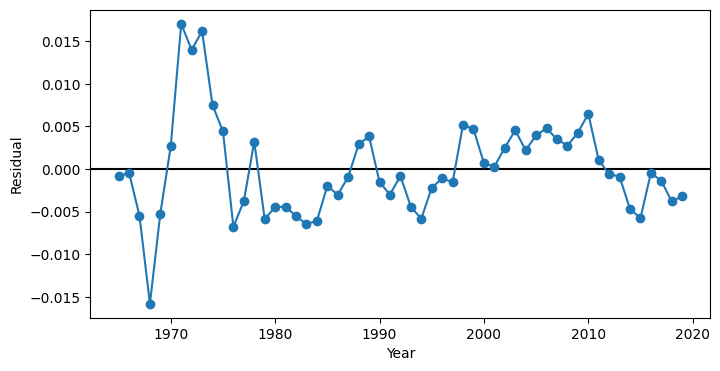

In [10]:
fit["pred"] = model(x, *pars)
fit["residual"] = fit["rdc"] - fit["pred"]

plt.figure(figsize=(8,4))
plt.axhline(0, color="k")
plt.plot(fit.index, fit["residual"], "o-")
plt.ylabel("Residual")
plt.xlabel("Year")
plt.savefig("../bomb/img/residual.pdf")

print("residual std: ", fit["residual"].std())
print("residual median: ", fit["residual"].median())
from scipy.stats import skew

print("residual skewness: ", skew(fit["residual"]))
print("residual skewness unbiased: ", skew(fit["residual"], bias=False))


reg = linregress(x, fit["residual"])
print("linear slope: ", reg.slope)


<Axes: xlabel='Lag', ylabel='Autocorrelation'>

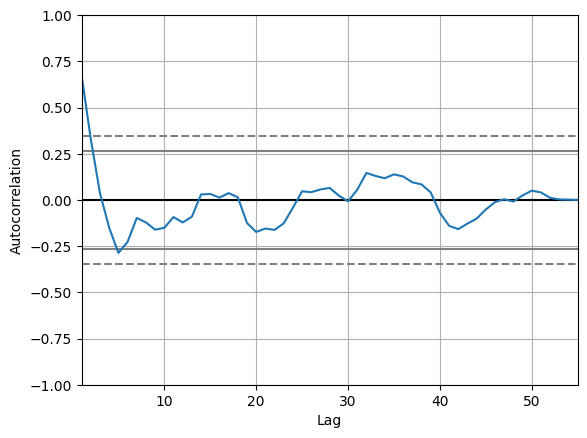

In [11]:
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(fit["residual"])

In [12]:
print("residual[10:] std: ", fit["residual"][10:].std())
print("residual[10:] skewness: ", skew(fit["residual"][10:]))
reg = linregress(x[10:], fit["residual"][10:])
print("residual10 linear slope: ", reg.slope)

residual[10:] std:  0.003842973494352788
residual[10:] skewness:  0.10969010269648535
residual10 linear slope:  8.108103213145938e-05


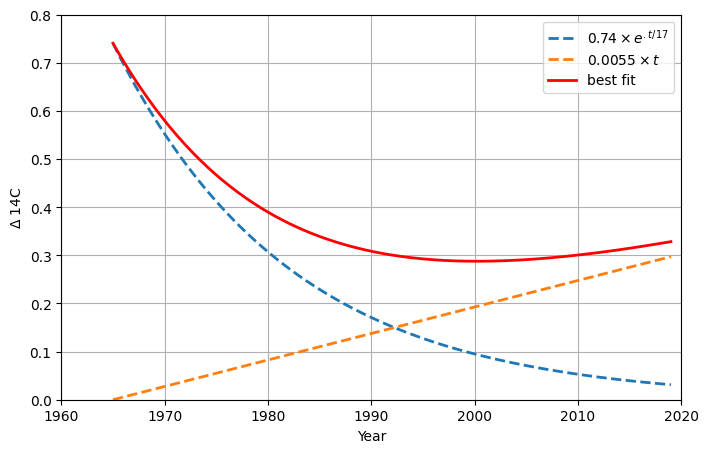

In [13]:
def regr(x, A, k):
    return A * np.exp(-k * (x - t0))

def lin(x, C):
    return C * (x - t0)
    
const = np.empty(300)
const.fill(1)

xx = np.linspace(1965, 2019, 300)

plt.figure(figsize=(8,5))

plt.plot(xx, regr(xx, A, k), lw=2, linestyle='dashed', label="$0.74\\times e^{.t/17}$")

plt.plot(xx, lin(xx, C), lw=2, linestyle='dashed', label="$0.0055\\times t$")

plt.plot(xx, regr(xx, A, k) + lin(xx,C), lw=2, color="red", label="best fit")
plt.ylim((0,0.8))

plt.xlim((1960,2020))
plt.grid()

plt.xlabel("Year")
plt.ylabel(r"$\Delta$ 14C")
plt.legend()
plt.savefig("../bomb/img/terms.pdf")
plt.show()

    

In [14]:
bomb

,ppm,gtc,dc14,dc,rdc
year,,,,,
1959,315.981667,673.040950,1.188,1.019296,1.210923
1960,316.908333,675.014750,1.200,1.022285,1.226742
1961,317.643333,676.580300,1.212,1.024656,1.241883
1962,318.453333,678.305600,1.278,1.027269,1.312850
1963,318.992500,679.454025,1.514,1.029008,1.557918
...,...,...,...,...,...
2015,401.012500,854.156625,1.018,1.293589,1.316873
2016,404.412500,861.398625,1.016,1.304556,1.325429
2017,406.758333,866.395250,1.012,1.312124,1.327869


In [33]:
path_name = '../data/Global_Carbon_Budget_2025_v0.6.csv'

fossil = pd.read_csv( path_name,
    comment="#",
    sep=";",
    decimal=",",
    dtype={"Year": "int64"}
)

fossil["Other"] = fossil[["Cement", "Flaring", "Other"]].sum(axis=1)





In [34]:
section = fossil.loc[(fossil["Year"] >= 1965 ) & (fossil["Year"] <= 2019)]

model = pd.DataFrame(index  = section["Year"], 
                          data={"emi": section["Total"].values, 
                                "keeling" : co2.loc[(co2.index >= 1965 ) & (co2.index <= 2019)]["average"].values *2.13,
                                "bomb" : bomb.loc[bomb.index >= 1965]["dc14"].values})

year0 = 1965

atm0 =  model.loc[year0, "keeling"]
ac140 = model.loc[year0, "bomb"]
oc140 = 1

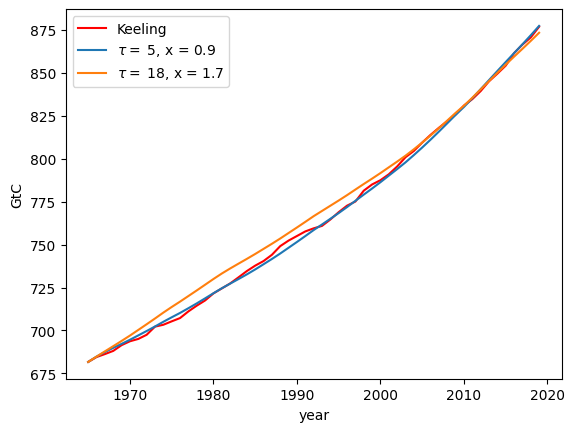

In [72]:

sims = [(0.9,5), (1.7,18)]

plt.plot(model.index, model["keeling"], label="Keeling", color="red")

atm =  [0.0] *len(model)
ocean = [0.0] *len(model)

atm[0] = atm0

for (x,tau) in sims:
  ocean[0] = atm0 * x
  my = (1 - np.exp(-1/tau)) / x
  for y in (range(1, len(model))) :
    to_ocean = (1 - np.exp(-1/tau)) * atm[y-1]
    from_ocean = my * ocean[y-1]
    emi = model.loc[1965+y-1,"emi"]
    atm[y] =  atm[y-1] - to_ocean + from_ocean  + emi
    ocean[y] = ocean[y-1] + to_ocean - from_ocean
  plt.plot(model.index, atm, label= f"$\\tau =$ {tau}, x = {x}")

plt.ylabel("GtC")
plt.xlabel("year")
plt.legend()
plt.savefig("../bomb/img/keeling-fit.pdf")

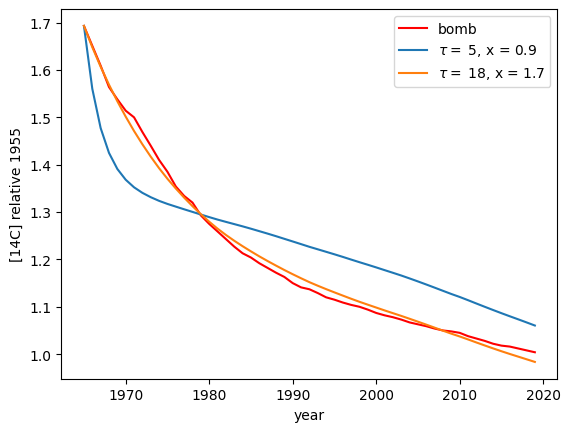

In [18]:
sims = [(0.9,5), (1.7,18)]

year0 = 1965

atm =  [0.0] * len(model)
ocean = [0.0] * len(model)
ac14 =  [0.0] * len(model)  # atmospheric 14C concentrations
oc14 =  [0.0] * len(model)  # ocean 14C concentrations
atm[0] = atm0
ac14[0] = ac140
oc14[0] = oc140

plt.plot(model.index, model["bomb"], label="bomb", color="red")

for (x,tau) in sims:
  ocean[0] = atm0 * x
  my = (1 - np.exp(-1/tau)) / x
  for y in (range(1, len(model))) :
    to_ocean = (1 - np.exp(-1/tau)) * atm[y-1]
    from_ocean = my * ocean[y-1]
    emi = model.loc[year0+y-1,"emi"]
    atm[y] =  atm[y-1] - to_ocean + from_ocean  + emi
    ocean[y] = ocean[y-1] + to_ocean - from_ocean
    ac14[y] = (atm[y-1]*ac14[y-1] - to_ocean*ac14[y-1] + from_ocean*oc14[y-1])/atm[y]
    oc14[y] = (ocean[y-1]*oc14[y-1] + to_ocean*ac14[y-1] - from_ocean*oc14[y-1])/ocean[y]
  plt.plot(model.index, ac14, label= f"$\\tau =$ {tau}, x = {x}")
plt.legend()
plt.ylabel("[14C] relative 1955")
plt.xlabel("year")
plt.savefig("../bomb/img/bomb-fit.pdf")


x = 2, tau = 18


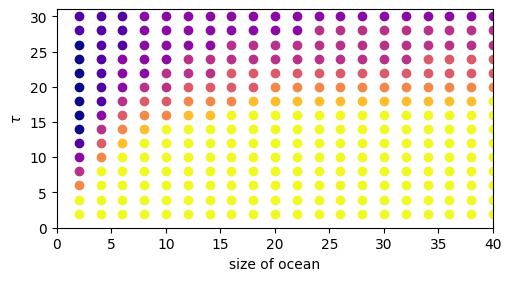

In [19]:
taus = range(2,31,2)
xs = range(2,41,2)



year0 = 1965

atm =  [0.0] * len(model)
ocean = [0.0] * len(model)
ac14 =  [0.0] * len(model)  # atmospheric 14C concentrations
oc14 =  [0.0] * len(model)  # ocean 14C concentrations
atm[0] = atm0
ac14[0] = ac140
oc14[0] = oc140

fig, ax = plt.subplots(figsize=(5, 2.7), layout='constrained')
colors = mpl.colormaps['plasma'].resampled(8)
ax.set_xlim(0,40)
ax.set_ylim(0,31)

min = 10000
max = 0

for x in xs :
    for tau in taus :
        ocean[0] = atm0 * x
        my = (1 - np.exp(-1/tau)) / x
        for y in (range(1, len(model))) :
            to_ocean = (1 - np.exp(-1/tau)) * atm[y-1]
            from_ocean = my * ocean[y-1]
            emi = model.loc[year0+y-1,"emi"]
            atm[y] =  atm[y-1] - to_ocean + from_ocean  + emi
            ocean[y] = ocean[y-1] + to_ocean - from_ocean
            ac14[y] = ((atm[y-1] - to_ocean )*ac14[y-1] + from_ocean*oc14[y-1])/atm[y]
            oc14[y] = ((ocean[y-1] - from_ocean) *oc14[y-1] + to_ocean*ac14[y-1])/ocean[y]
        mean = st.mean([ i ** 2 for i in (model.loc[:, "bomb"].values - ac14)])
        ax.scatter(x, tau, color=colors(mean*100))
        if mean < min : 
            min = mean
            x_min = x
            tau_min = tau
        if mean > max : max = mean
            
ax.set_xlabel("size of ocean")
ax.set_ylabel("$\\tau$")  
plt.savefig("../bomb/img/bomb-heat.pdf")
print(f"x = {x_min}, tau = {tau_min}")      

x = 1.7999999999999998, tau = 18


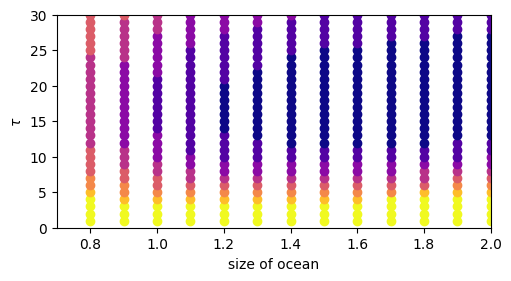

In [20]:
taus = range(1,31,1)
xs = np.linspace(0.8, 2, num=13)



year0 = 1965

atm =  [0.0] * len(model)
ocean = [0.0] * len(model)
ac14 =  [0.0] * len(model)  # atmospheric 14C concentrations
oc14 =  [0.0] * len(model)  # ocean 14C concentrations
atm[0] = atm0
ac14[0] = ac140
oc14[0] = oc140

fig, ax = plt.subplots(figsize=(5, 2.7), layout='constrained')
colors = mpl.colormaps['plasma'].resampled(8)
ax.set_xlim(0.7,2)
ax.set_ylim(0,30)

min = 10000
max = 0

for x in xs :
    for tau in taus :
        ocean[0] = atm0 * x
        my = (1 - np.exp(-1/tau)) / x
        for y in (range(1, len(model))) :
            to_ocean = (1 - np.exp(-1/tau)) * atm[y-1]
            from_ocean = my * ocean[y-1]
            emi = model.loc[year0+y-1,"emi"]
            atm[y] =  atm[y-1] - to_ocean + from_ocean  + emi
            ocean[y] = ocean[y-1] + to_ocean - from_ocean
            ac14[y] = ((atm[y-1] - to_ocean )*ac14[y-1] + from_ocean*oc14[y-1])/atm[y]
            oc14[y] = ((ocean[y-1] - from_ocean) *oc14[y-1] + to_ocean*ac14[y-1])/ocean[y]
        mean = st.mean([ i ** 2 for i in (model.loc[:, "bomb"].values - ac14)])
        ax.scatter(x, tau, color=colors(mean*100))
        if mean < min : 
            min = mean
            x_min = x
            tau_min = tau
        if mean > max : max = mean
            
ax.set_xlabel("size of ocean")
ax.set_ylabel("$\\tau$")  

print(f"x = {x_min}, tau = {tau_min}")

x = 2, tau = 18


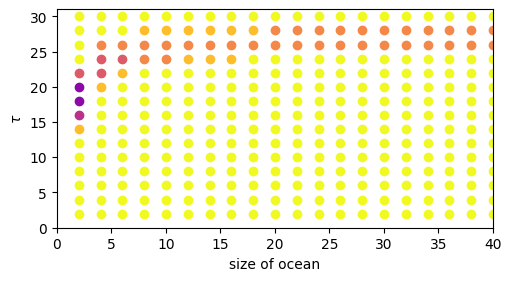

In [21]:
taus = range(2,31,2)
xs = range(2,41,2)


year0 = 1965

atm =  [0.0] *len(model)
ocean = [0.0] *len(model)
ac14 =  [0.0] *len(model)  # atmospheric 14C concentrations
oc14 =  [0.0] *len(model)  # ocean 14C concentrations
atm[0] = atm0
ac14[0] = ac140
oc14[0] = oc140

fig, ax = plt.subplots(figsize=(5, 2.7), layout='constrained')
colors = mpl.colormaps['plasma'].resampled(8)
ax.set_xlim(0,40)
ax.set_ylim(0,31)

min = 10000
max = 0

for x in xs :
    for tau in taus :
        ocean[0] = atm0 * x
        my = (1 - np.exp(-1/tau)) / x
        for y in (range(1, len(model))) :
            to_ocean = (1 - np.exp(-1/tau)) * atm[y-1]
            from_ocean = my * ocean[y-1]
            emi = model.loc[year0+y-1,"emi"]
            atm[y] =  atm[y-1] - to_ocean + from_ocean  + emi
            ocean[y] = ocean[y-1] + to_ocean - from_ocean
        mean = st.mean([ i ** 2 for i in (model.loc[:, "keeling"].values - atm)])
        if mean < min : 
            min = mean
            x_min = x
            tau_min = tau
        if mean > max : max = mean
        ax.scatter(x, tau, color=colors(mean/100))

ax.set_xlabel("size of ocean")
ax.set_ylabel("$\\tau$")
plt.savefig("../bomb/img/keeling-heat.pdf")
print(f"x = {x_min}, tau = {tau_min}")

x = 0.9, tau = 5


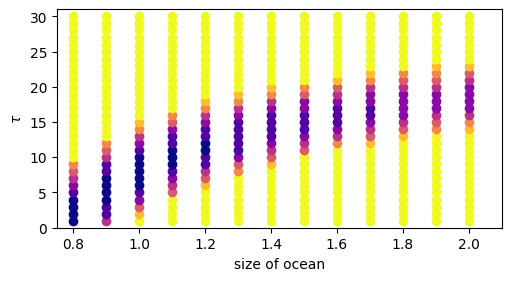

In [22]:
taus = range(1,31,1)
xs = np.linspace(0.8, 2, num=13)


year0 = 1965

atm =  [0.0] *len(model)
ocean = [0.0] *len(model)
ac14 =  [0.0] *len(model)  # atmospheric 14C concentrations
oc14 =  [0.0] *len(model)  # ocean 14C concentrations
atm[0] = atm0
ac14[0] = ac140
oc14[0] = oc140

fig, ax = plt.subplots(figsize=(5, 2.7), layout='constrained')
colors = mpl.colormaps['plasma'].resampled(8)
ax.set_xlim(0.75,2.1)
ax.set_ylim(0,31)

min = 10000
max = 0

for x in xs :
    for tau in taus :
        ocean[0] = atm0 * x
        my = (1 - np.exp(-1/tau)) / x
        for y in (range(1, len(model))) :
            to_ocean = (1 - np.exp(-1/tau)) * atm[y-1]
            from_ocean = my * ocean[y-1]
            emi = model.loc[year0+y-1,"emi"]
            atm[y] =  atm[y-1] - to_ocean + from_ocean  + emi
            ocean[y] = ocean[y-1] + to_ocean - from_ocean
        mean = st.mean([ i ** 2 for i in (model.loc[:, "keeling"].values - atm)])
        if mean < min : 
            min = mean
            x_min = x
            tau_min = tau
        if mean > max : max = mean
        ax.scatter(x, tau, color=colors(mean/100))

ax.set_xlabel("size of ocean")
ax.set_ylabel("$\\tau$")
print(f"x = {x_min}, tau = {tau_min}")

In [23]:
x = 40
tau = 18

year0 = 1965

atm =  [0.0] *len(model)
ocean = [0.0] *len(model)
ac14 =  [0.0] *len(model)  # atmospheric 14C concentrations
oc14 =  [0.0] *len(model)  # ocean 14C concentrations
atm[0] = atm0
ac14[0] = ac140
oc14[0] = oc140


ocean[0] = atm0 * x
my = (1 - np.exp(-1/tau)) / x
for y in (range(1, len(model))) :
  to_ocean = (1 - np.exp(-1/tau)) * atm[y-1]
  from_ocean = my * ocean[y-1]
  emi = model.loc[year0+y-1,"emi"]
  atm[y] =  atm[y-1] - to_ocean + from_ocean  + emi
  ocean[y] = ocean[y-1] + to_ocean - from_ocean
  ac14[y] = (atm[y-1]*ac14[y-1] - to_ocean*ac14[y-1] + from_ocean*oc14[y-1])/atm[y]
  oc14[y] = (ocean[y-1]*oc14[y-1] + to_ocean*ac14[y-1] - from_ocean*oc14[y-1])/ocean[y]
  print(f"year = {1965+y}, ac14 = {ac14[y]}, oc14 = {oc14[y]}")

year = 1966, ac14 = 1.648086610587005, oc14 = 1.0009362522011902
year = 1967, ac14 = 1.6056698681068788, oc14 = 1.0018145148304227
year = 1968, ac14 = 1.5657072901957767, oc14 = 1.002637685808224
year = 1969, ac14 = 1.527865110607341, oc14 = 1.003408599956334
year = 1970, ac14 = 1.4919103692038085, oc14 = 1.0041297772524151
year = 1971, ac14 = 1.4575825758420022, oc14 = 1.004803496457035
year = 1972, ac14 = 1.4251013801002765, oc14 = 1.005431758018507
year = 1973, ac14 = 1.3942929358992822, oc14 = 1.0060167416785428
year = 1974, ac14 = 1.3649916024946063, oc14 = 1.0065604442844538
year = 1975, ac14 = 1.3375923187965166, oc14 = 1.0070646810248804
year = 1976, ac14 = 1.311922958350447, oc14 = 1.00753167504194
year = 1977, ac14 = 1.2874303335435444, oc14 = 1.007963489661211
year = 1978, ac14 = 1.2642347554146207, oc14 = 1.0083615934937897
year = 1979, ac14 = 1.2421771079916164, oc14 = 1.0087275807071685
year = 1980, ac14 = 1.2212763273616902, oc14 = 1.0090628645643744
year = 1981, ac14 = 

In [26]:
fossil.info()

<class 'pandas.DataFrame'>
RangeIndex: 55 entries, 115 to 169
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Year     55 non-null     int64  
 1   Total    55 non-null     float64
 2   Coal     55 non-null     float64
 3   Oil      55 non-null     float64
 4   Gas      55 non-null     float64
 5   Cement   55 non-null     float64
 6   Flaring  55 non-null     float64
 7   Other    55 non-null     float64
 8   Capita   55 non-null     float64
dtypes: float64(8), int64(1)
memory usage: 4.0 KB


In [67]:
century = pd.DataFrame(index  = fossil["Year"], 
                          data={"emi": fossil["Total"].values})

century0 = 1850
atmc0 = 280 * 2.13  # assumed value pre-industry



 2019  874.614390889435


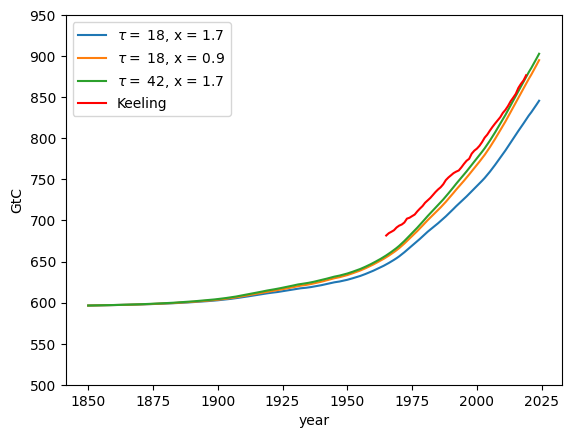

In [89]:
sims = [(1.7,18),(0.9,18),(1.7,42)]


atm =  [0.0] * len(century)
ocean = [0.0] * len(century)

atm[0] = atmc0

for (x,tau) in sims:
  ocean[0] = atm[0] * x
  my = (1 - np.exp(-1/tau)) / x
  for y in (range(1, len(century))) :
    to_ocean = (1 - np.exp(-1/tau)) * atm[y-1]
    from_ocean = my * ocean[y-1]
    emi = century.loc[century0+y-1,"emi"]
    atm[y] =  atm[y-1] - to_ocean + from_ocean  + emi
    ocean[y] = ocean[y-1] + to_ocean - from_ocean
  plt.plot(century.index, atm, label= f"$\\tau =$ {tau}, x = {x}")

plt.plot(model.index, model["keeling"], label="Keeling", color="red")

plt.ylim((500,950))
plt.ylabel("GtC")
plt.xlabel("year")
plt.legend()
plt.savefig("../bomb/img/century.pdf")

print(" 2019 ", atm[2019-century0])

In [85]:
(model.loc[2019,"keeling"] - (280*2.13))

np.float64(280.4127249999999)

In [90]:
(875 - (280*2.13))

278.6

In [91]:
atm[2019-1850]

np.float64(874.614390889435)

In [99]:
model.loc[2019,"keeling"] 

np.float64(876.8127249999999)

In [98]:
atm[2019-1850]

np.float64(874.614390889435)